# **Sesión práctica 4: Detección de datos atípicos**

In [11]:
# Cargar dependencias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor

## **Ejercicio 1: Intervalo IQR**

A partir de siguiente código:

1.   Ajustar el código para mejorar la interpretación de la gráfica. Mínimo debe:

*   Indicar los nombres de los ejes
*   Incluir leyenda para comprender lo que esté incluído en la gráfica


2.   Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

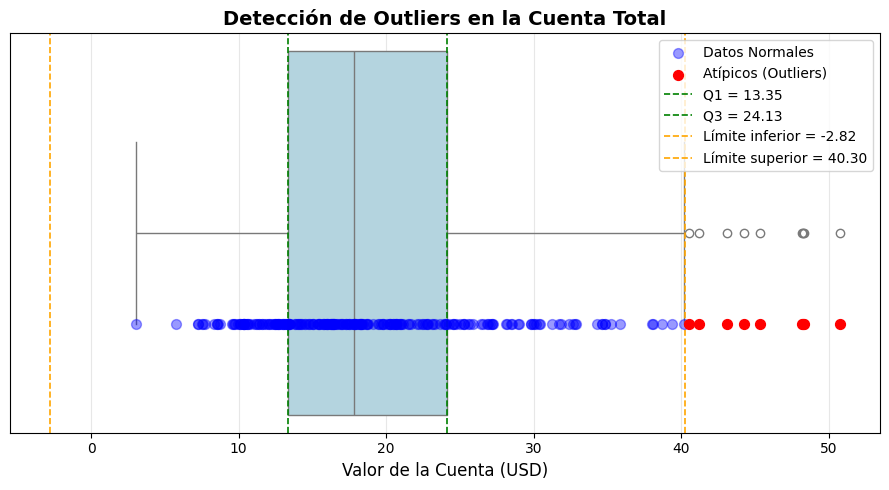

In [ ]:
tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values

Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(9,5))

sns.boxplot(x=total_bill, color="lightblue", width=0.4)

plt.scatter(data_b, [0.1]*len(data_b), color="blue", s=50, alpha=0.4, label="Datos Normales", zorder=5)
plt.scatter(data_a, [0.1]*len(data_a), color="red", s=50, label="Atípicos (Outliers)", zorder=5)

plt.axvline(Q1, color="green", linestyle="--", linewidth=1.2, label=f"Q1 = {Q1:.2f}")
plt.axvline(Q3, color="green", linestyle="--", linewidth=1.2, label=f"Q3 = {Q3:.2f}")
plt.axvline(lim_inf, color="orange", linestyle="--", linewidth=1.2, label=f"Límite inferior = {lim_inf:.2f}")
plt.axvline(lim_sup, color="orange", linestyle="--", linewidth=1.2, label=f"Límite superior = {lim_sup:.2f}")

plt.title("Detección de Outliers en la Cuenta Total", fontsize=14, weight="bold")
plt.xlabel("Valor de la Cuenta (USD)", fontsize=12)
plt.yticks([])
plt.legend(loc="upper right")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### **Análisis**
Todos los datos atípicos se encuentran fuera del límite superior del boxplot, no se encuentra ninguno al lado izquierdo; siendo casos aislados, pues no se observa una cantidad considerable de estos. También es posible visualizar que los datos presentan una distribución con un sesgo positivo, cuyos valores atípicos empiezan con valores de la cuenta desde los 40USD.

## **Ejercicio 2: Graficos de dispersión**

A partir de siguiente código:

1.   Ajustar el código para mejorar la interpretación de la gráfica. Mínimo debe:

*   Indicar los nombres de los ejes
*   Incluir leyenda para comprender lo que esté incluído en la gráfica


2.   Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

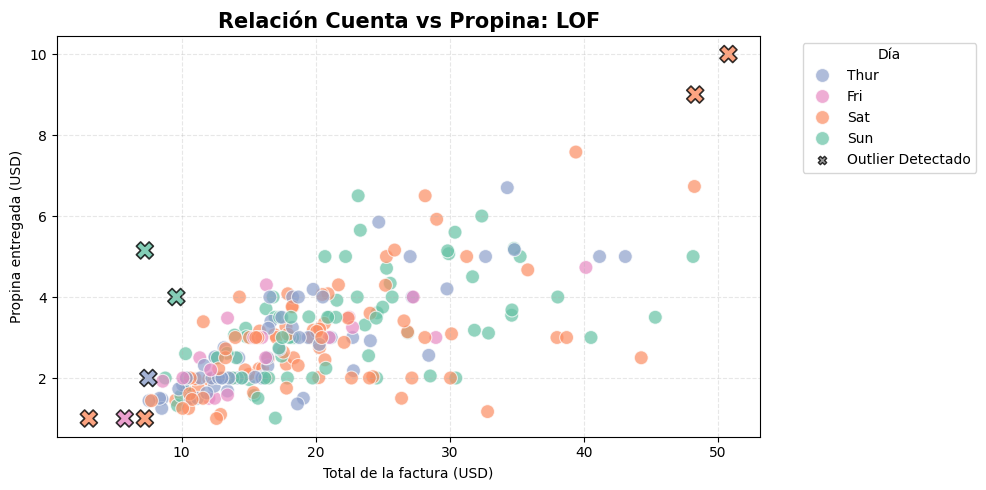

In [ ]:
tips = sns.load_dataset("tips")
x_values = tips[["total_bill", "tip"]].values

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
tips['is_outlier'] = lof.fit_predict(x_values)
tips['is_outlier'] = tips['is_outlier'].apply(lambda x: 'Outlier' if x == -1 else 'Normal')

colores_dias = sns.color_palette("Set2", n_colors=len(tips["day"].unique()))
paleta_fija = dict(zip(tips["day"].unique(), colores_dias))

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=tips[tips['is_outlier'] == 'Normal'],
    x="total_bill",
    y="tip",
    hue="day",
    palette=paleta_fija,
    s=100,
    alpha=0.7,
    legend='brief'
)

sns.scatterplot(
    data=tips[tips['is_outlier'] == 'Outlier'],
    x="total_bill",
    y="tip",
    hue="day",
    palette=paleta_fija,
    marker="X",
    s=150,
    edgecolor="black",
    linewidth=1.2,
    alpha=0.8,
    legend=False
)

plt.scatter([], [], marker='X', color='gray', label='Outlier Detectado',
            edgecolor='black', alpha=0.8)

plt.title("Relación Cuenta vs Propina: LOF", fontsize=15, fontweight='bold')
plt.xlabel("Total de la factura (USD)")
plt.ylabel("Propina entregada (USD)")

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title="Día", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### **Análisis**
Existen datos atípicos univariados, como una cuenta mayor a los 40USD con una propina baja (entre 2USD y 4USD). Al igual que puntos atípicos multivariados, como una cuenta mayor a los 40USD con una propina alta (cercana a los 8USD), y un dato atípico global (Factura > 50USD y Propina = 10USD). También se observa que la mayoría de atípicos se dan durante y el día sábado (`Sat`). La mayoría de los datos se agrupan por debajo de los 30USD (`Total de la factura`) y de los 6USD (`Propina Entregada`).

## **Ejercicio 3: Histogramas y funciones de densidad**

A partir de siguiente código:

1.   Ajustar el código para mejorar la interpretación de la gráfica. Mínimo debe:

*   Indicar los nombres de los ejes
*   Incluir leyenda para comprender lo que esté incluído en la gráfica


2.   Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

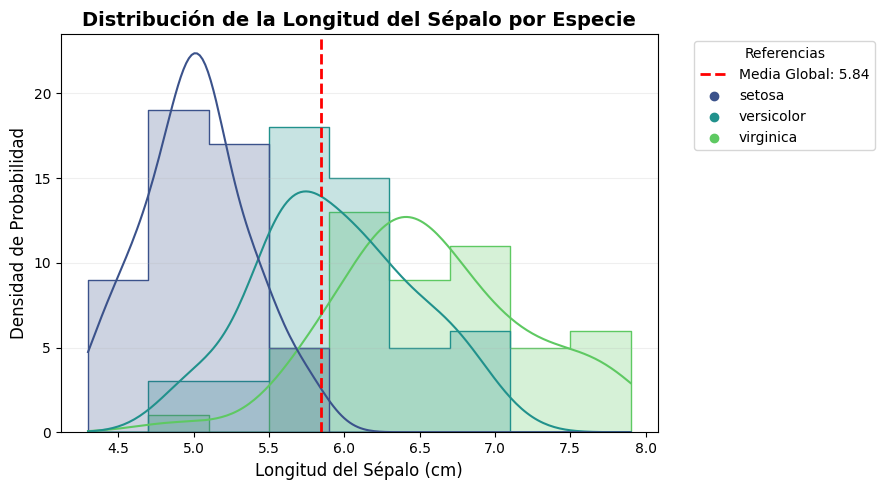

In [ ]:
iris = sns.load_dataset("iris")
x = iris["sepal_length"].values
especies = iris["species"].unique()

colores = sns.color_palette("viridis", n_colors=len(especies))
paleta_dict = dict(zip(especies, colores))

plt.figure(figsize=(9,5))

ax = sns.histplot(data=iris, x="sepal_length", hue="species", kde=True, palette=paleta_dict, element="step", common_norm=False, legend=False)

media = np.mean(x)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f"Media Global: {media:.2f}")

for sp in especies:
    ax.scatter([], [], color=paleta_dict[sp], label=sp)

plt.title("Distribución de la Longitud del Sépalo por Especie", fontsize=14, weight="bold")
plt.xlabel("Longitud del Sépalo (cm)", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)

plt.legend(title="Referencias", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

### **Análisis**
La gráfica muestra una distribución donde la variabilidad de las especies explica la dispersión sin presencia de atípicos globales. No se identifican atípicos univariados extremos, pues todos la mayoría de datos se mantienen dentro de un rango entre 4.5 a 7.5 cm. Sin embargo, existen potenciales atípicos locales en los extremos de las especies `versicolor` y `virginica`, donde algunos individuos se alejan significativamente de su tendencia grupal. Se observa a la especie `setosa` como un grupo aislado, situado totalmente a la izquierda de la media global. Por lo que se puede concluir que la "anomalía" se debe a una diversidad biológica.

## **Ejercicio 4: Z-Score**

A partir de siguiente código:

1.   Ajustar el código para mejorar la interpretación de la gráfica. Mínimo debe:

*   Indicar los nombres de los ejes
*   Incluir leyenda para comprender lo que esté incluído en la gráfica


2.   Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

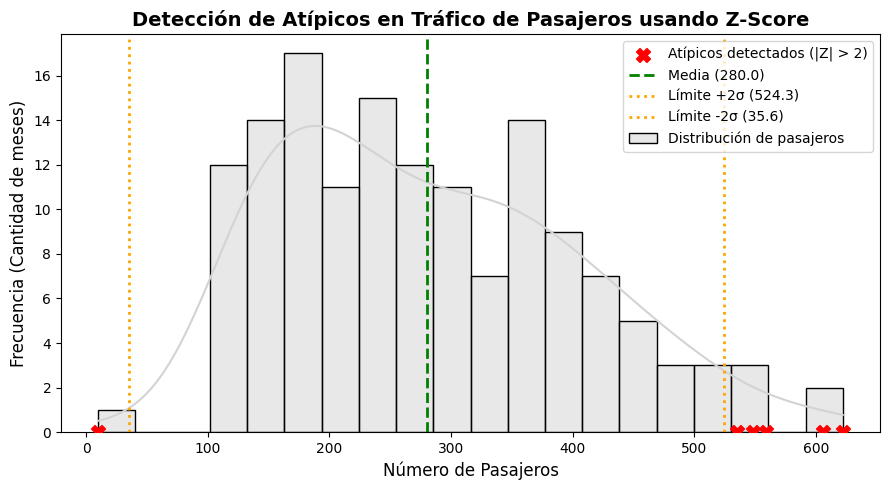

In [12]:
flights = sns.load_dataset("flights")
x = flights["passengers"].values
x = np.append(x, [10, 500])

z_scores = zscore(x)
data_b = np.abs(z_scores) > 2

plt.figure(figsize=(9,5))

sns.histplot(x=x, bins=20, kde=True, color="lightgray", label="Distribución de pasajeros")

plt.scatter(x[data_b], np.zeros_like(x[data_b]), color="red", s=100, marker="X", zorder=5, label="Atípicos detectados (|Z| > 2)")

media = np.mean(x)
desviacion = np.std(x)

plt.axvline(media, color="green", linestyle="--", linewidth=2, label=f"Media ({media:.1f})")
plt.axvline(media + 2*desviacion, color="orange", linestyle=":", linewidth=2, label=f"Límite +2σ ({media + 2*desviacion:.1f})")
plt.axvline(media - 2*desviacion, color="orange", linestyle=":", linewidth=2, label=f"Límite -2σ ({media - 2*desviacion:.1f})")

plt.title("Detección de Atípicos en Tráfico de Pasajeros usando Z-Score", fontsize=14, weight="bold")
plt.xlabel("Número de Pasajeros", fontsize=12)
plt.ylabel("Frecuencia (Cantidad de meses)", fontsize=12)

plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

##Analisis:
Evaluamos el volumen historicos de los pasajeros, los limites son un volumen normal, los datos atipicos son meses con muy pocos pasajeros o con picos muy altos, donde no es tan normal que el numero de pasajeros sea bajo hay menos atipicos, sin embargo, no se tienen en cuenta otras variables como, precios y si son meses de temporadas o no, que puede ser el porque de los datos atipicos, esto pasa porque el metodo mide de manera univariada el volumen de los pasajeros




## **Ejercicio 5: K-means**

A partir de siguiente código:

1.   Ajustar el código para mejorar la interpretación de la gráfica. Mínimo debe:

*   Indicar los nombres de los ejes
*   Incluir leyenda para comprender lo que esté incluído en la gráfica


2.   Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

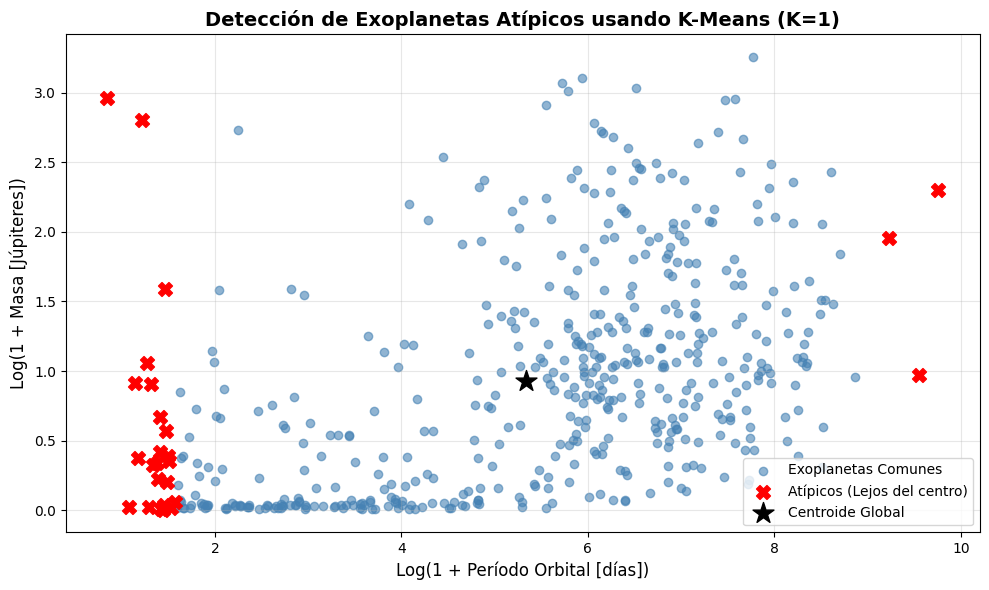

In [ ]:
##no hacer nada

##Analisis:
